In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_context("talk")
sns.set_style("whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
#!pip install pandas
# !pip install seaborn

In [3]:
DATA_PATH = Path("/home/artemis/project/datasets/explore-eqa/questions_msp_sample_1_metric_corrected.csv")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
df.head(3)

Loaded: (44, 36)


,scene,floor,source_question,primary_object,distance_m,predicate,msp_question,ann_ok,ann_ts,ann_pos_x,ann_pos_y,ann_pos_z,ann_yaw_rad,ann_m,ann_n,ann_scale_x,ann_scale_y,ann_scale_z,ann_aabb_min_x,ann_aabb_min_y,ann_aabb_min_z,ann_aabb_max_x,ann_aabb_max_y,ann_aabb_max_z,ann_volume,anchor_sid,anchor_label,anchor_center_x,anchor_center_y,anchor_center_z,metric_corrected_x,metric_corrected_y,metric_corrected_z,ann_dist_m,metric_error_m,metric_corrected_ok
0,00410-v7DzfFFEpsD,1,Which side of the front door is the plant now?,sofa,3.0,in front of,What object is 3.0 meters in front of the 2 se...,1.0,1.771201e+09,12.270763,0.626357,-0.159691,1.263488,2.0,2.0,0.15,0.15,0.15,12.120998,0.476434,-0.309560,12.420507,0.776085,-0.009780,0.014187,10.0,sofa,8.274635,0.488885,-0.412103,11.266905,0.591823,-0.223099,4.006451,1.006451,True
1,00262-1xGrZPxG1Hz,0,Are the candles by the entracne put out?,floor lamp,1.8,in front of,What object is 1.8 meters in front of the floo...,1.0,1.771201e+09,-4.610894,1.591614,1.170438,1.595088,2.0,2.0,0.15,0.15,0.15,-4.760850,1.442069,1.020575,-4.460938,1.741330,1.320186,0.014187,344.0,floor lamp,-1.035627,0.518089,0.874393,-2.754193,1.034113,1.016696,3.744681,1.944681,True
2,00256-92vYG1q49FY,0,Is the air conditioning at the entrance turned...,air conditioner,2.0,in front of,Where is 2 meter in front of air conditioner?,1.0,1.771201e+09,-0.664546,-0.608228,0.502032,0.184000,2.0,2.0,0.15,0.15,0.15,-0.814545,-0.757861,0.352287,-0.514823,-0.458595,0.651770,0.014187,647.0,air conditioning,-0.592708,-0.266122,-1.072894,-0.681768,-0.690241,0.879589,1.613254,-0.386746,True


In [4]:
# --- Select + reshape the evaluation frame ---

cols = [
    "scene",
    "msp_question",
    "distance_m",
    "ann_pos_x", "ann_pos_y", "ann_pos_z",
    "anchor_center_x", "anchor_center_y", "anchor_center_z",
    "metric_corrected_x", "metric_corrected_y", "metric_corrected_z",
]

# keep only cols that exist (helps if a name differs slightly)
missing = [c for c in cols if c not in df.columns]
assert not missing, f"Missing columns in df: {missing}"

eval_df = df[cols].copy()

# Rename to cleaner names (optional but nice for plots/tables)
eval_df = eval_df.rename(columns={
    "msp_question": "msp_question",
    "distance_m": "gt_metric_distance_m",
    "ann_pos_x": "ann_x", "ann_pos_y": "ann_y", "ann_pos_z": "ann_z",
    "anchor_center_x": "anchor_x", "anchor_center_y": "anchor_y", "anchor_center_z": "anchor_z",
    "metric_corrected_x": "corr_x", "metric_corrected_y": "corr_y", "metric_corrected_z": "corr_z",
})

# Enumerated id starting from 1
eval_df.insert(0, "id", np.arange(1, len(eval_df) + 1))

print("eval_df:", eval_df.shape)
eval_df.head(5)

eval_df: (44, 13)


,id,scene,msp_question,gt_metric_distance_m,ann_x,ann_y,ann_z,anchor_x,anchor_y,anchor_z,corr_x,corr_y,corr_z
0,1,00410-v7DzfFFEpsD,What object is 3.0 meters in front of the 2 se...,3.0,12.270763,0.626357,-0.159691,8.274635,0.488885,-0.412103,11.266905,0.591823,-0.223099
1,2,00262-1xGrZPxG1Hz,What object is 1.8 meters in front of the floo...,1.8,-4.610894,1.591614,1.170438,-1.035627,0.518089,0.874393,-2.754193,1.034113,1.016696
2,3,00256-92vYG1q49FY,Where is 2 meter in front of air conditioner?,2.0,-0.664546,-0.608228,0.502032,-0.592708,-0.266122,-1.072894,-0.681768,-0.690241,0.879589
3,4,00525-iKFn6fzyRqs,Where is 2.2 meters right of the bed?,2.2,-0.804381,1.160079,2.587379,-0.824080,0.620257,-0.086800,-0.808195,1.055567,2.069645
4,5,00366-fxbzYAGkrtm,Where is 1 meters right of the bathtub?,1.0,0.235436,1.136391,13.243641,1.531338,0.308540,6.544282,1.342804,0.428980,7.518935


In [5]:
# Distances from anchor to annotated + corrected points
anchor = eval_df[["anchor_x", "anchor_y", "anchor_z"]].to_numpy()
ann    = eval_df[["ann_x", "ann_y", "ann_z"]].to_numpy()
corr   = eval_df[["corr_x", "corr_y", "corr_z"]].to_numpy()

eval_df["anchor_to_ann_dist_m"]  = np.linalg.norm(ann - anchor, axis=1)
eval_df["anchor_to_corr_dist_m"] = np.linalg.norm(corr - anchor, axis=1)

eval_df[["id", "gt_metric_distance_m", "anchor_to_ann_dist_m", "anchor_to_corr_dist_m"]]

,id,gt_metric_distance_m,anchor_to_ann_dist_m,anchor_to_corr_dist_m
0,1,3.0,4.006451,3.0
1,2,1.8,3.744681,1.8
2,3,2.0,1.613254,2.0
3,4,2.2,2.728192,2.2
4,5,1.0,6.873581,1.0
5,6,2.0,7.751035,2.0
6,7,1.0,4.559011,1.0
7,8,1.5,1.384289,1.5
8,9,0.5,1.690146,0.5
9,10,3.0,4.154231,3.0


In [6]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_JSON = Path("/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_msp2/mspwhere/results_where.json")
assert RESULTS_JSON.exists(), f"File not found: {RESULTS_JSON}"

with open(RESULTS_JSON, "r") as f:
    results = json.load(f)

def _safe_get(d, path, default=None):
    cur = d
    for k in path:
        if cur is None:
            return default
        if isinstance(k, int):
            if isinstance(cur, list) and 0 <= k < len(cur):
                cur = cur[k]
            else:
                return default
        else:
            if isinstance(cur, dict) and k in cur:
                cur = cur[k]
            else:
                return default
    return cur

rows = []
for k, v in results.items():
    # key format: "<idx>_<scene>_<floor>"  (based on your example)
    parts = k.split("_")
    idx = int(parts[0]) if parts and parts[0].isdigit() else None
    scene = parts[1] if len(parts) > 1 else None
    floor = parts[2] if len(parts) > 2 else None

    success = _safe_get(v, ["Success"], default=False)
    final_pred = _safe_get(v, ["metrics", "final_pred"], default=None)

    # point target: prefer final_pred.target_xyz_hab if present, else selector.point_guess.target_xyz_hab
    point_xyz = _safe_get(final_pred, ["target_xyz_hab"], default=None)
    if point_xyz is None:
        point_xyz = _safe_get(final_pred, ["selector", "point_guess", "target_xyz_hab"], default=None)

    # best object xyz: selector.best_object.target_xyz_hab
    obj_xyz = _safe_get(final_pred, ["selector", "best_object", "target_xyz_hab"], default=None)

    # coerce to xyz floats (or NaN)
    def to_xyz(arr):
        if isinstance(arr, (list, tuple)) and len(arr) == 3:
            return float(arr[0]), float(arr[1]), float(arr[2])
        return np.nan, np.nan, np.nan

    px, py, pz = to_xyz(point_xyz)
    ox, oy, oz = to_xyz(obj_xyz)

    rows.append({
        "id": (idx + 1) if idx is not None else np.nan,   # aligns with eval_df id (1-based)
        "scene": scene,
        "floor": floor,
        "vlm_success": bool(success),

        "vlm_suggested_target_x": px,
        "vlm_suggested_target_y": py,
        "vlm_suggested_target_z": pz,

        "vlm_suggested_object_x": ox,
        "vlm_suggested_object_y": oy,
        "vlm_suggested_object_z": oz,
    })

vlm_df = pd.DataFrame(rows).sort_values("id")
print("vlm_df:", vlm_df.shape)
vlm_df.head(5)

vlm_df: (19, 10)


,id,scene,floor,vlm_success,vlm_suggested_target_x,vlm_suggested_target_y,vlm_suggested_target_z,vlm_suggested_object_x,vlm_suggested_object_y,vlm_suggested_object_z
0,1,00410-v7DzfFFEpsD,1,True,14.068377,0.607284,1.859091,13.787545,0.425490,1.463109
1,2,00262-1xGrZPxG1Hz,0,True,-2.258970,1.386000,3.100219,-1.672395,1.832760,2.874992
2,3,00256-92vYG1q49FY,0,True,0.514973,-1.171635,-3.204222,0.564412,-1.262222,-2.105005
3,4,00525-iKFn6fzyRqs,1,True,-0.326325,2.929523,-0.019697,-1.678033,0.465808,1.727366
4,5,00366-fxbzYAGkrtm,1,True,1.167214,0.458121,13.066575,0.380369,0.687248,12.674901


In [7]:
# Merge (keeps eval_df order)
eval_df = eval_df.merge(
    vlm_df[[
        "id", "vlm_success",
        "vlm_suggested_target_x","vlm_suggested_target_y","vlm_suggested_target_z",
        "vlm_suggested_object_x","vlm_suggested_object_y","vlm_suggested_object_z",
    ]],
    on="id",
    how="left"
)

# Distances from anchor to VLM point and anchor to VLM best-object location
anchor = eval_df[["anchor_x","anchor_y","anchor_z"]].to_numpy()

vlm_point = eval_df[["vlm_suggested_target_x","vlm_suggested_target_y","vlm_suggested_target_z"]].to_numpy()
vlm_obj   = eval_df[["vlm_suggested_object_x","vlm_suggested_object_y","vlm_suggested_object_z"]].to_numpy()

eval_df["anchor_to_vlm_point_dist_m"]  = np.linalg.norm(vlm_point - anchor, axis=1)
eval_df["anchor_to_vlm_object_dist_m"] = np.linalg.norm(vlm_obj   - anchor, axis=1)

# Quick view
cols_preview = [
    "id","scene","gt_metric_distance_m",
    "anchor_to_ann_dist_m","anchor_to_corr_dist_m",
    "anchor_to_vlm_point_dist_m","anchor_to_vlm_object_dist_m",
    "vlm_success"
]
eval_df[cols_preview].head(20)

,id,scene,gt_metric_distance_m,anchor_to_ann_dist_m,anchor_to_corr_dist_m,anchor_to_vlm_point_dist_m,anchor_to_vlm_object_dist_m,vlm_success
0,1,00410-v7DzfFFEpsD,3.0,4.006451,3.0,6.224130,5.823454,True
1,2,00262-1xGrZPxG1Hz,1.8,3.744681,1.8,2.684053,2.477142,True
2,3,00256-92vYG1q49FY,2.0,1.613254,2.0,2.566996,1.842931,True
3,4,00525-iKFn6fzyRqs,2.2,2.728192,2.2,2.363254,2.011042,True
4,5,00366-fxbzYAGkrtm,1.0,6.873581,1.0,6.534162,6.249211,True
5,6,00388-pcpn6mFqFCg,2.0,7.751035,2.0,6.112271,6.491878,True
6,7,00706-YHmAkqgwe2p,1.0,4.559011,1.0,4.002584,4.475954,True
7,8,00582-TYDavTf8oyy,1.5,1.384289,1.5,4.886262,2.577682,True
8,9,00557-fRZhp6vWGw7,0.5,1.690146,0.5,2.604473,2.298459,True
9,10,00025-ixTj1aTMup2,3.0,4.154231,3.0,1.944712,1.691801,True


In [8]:
# Error = | measured_distance_from_anchor - gt_metric_distance_m |
eval_df["err_ann_m"]       = (eval_df["anchor_to_ann_dist_m"]      - eval_df["gt_metric_distance_m"]).abs()
eval_df["err_corr_m"]      = (eval_df["anchor_to_corr_dist_m"]     - eval_df["gt_metric_distance_m"]).abs()
eval_df["err_vlm_point_m"] = (eval_df["anchor_to_vlm_point_dist_m"]- eval_df["gt_metric_distance_m"]).abs()
eval_df["err_vlm_obj_m"]   = (eval_df["anchor_to_vlm_object_dist_m"]- eval_df["gt_metric_distance_m"]).abs()

# Quick sanity table
eval_df[[
    "id","scene","gt_metric_distance_m",
    "anchor_to_ann_dist_m","anchor_to_corr_dist_m",
    "anchor_to_vlm_point_dist_m","anchor_to_vlm_object_dist_m",
    "err_ann_m","err_corr_m","err_vlm_point_m","err_vlm_obj_m",
    "vlm_success"
]].head(10)

,id,scene,gt_metric_distance_m,anchor_to_ann_dist_m,anchor_to_corr_dist_m,anchor_to_vlm_point_dist_m,anchor_to_vlm_object_dist_m,err_ann_m,err_corr_m,err_vlm_point_m,err_vlm_obj_m,vlm_success
0,1,00410-v7DzfFFEpsD,3.0,4.006451,3.0,6.224130,5.823454,1.006451,1.332268e-15,3.224130,2.823454,True
1,2,00262-1xGrZPxG1Hz,1.8,3.744681,1.8,2.684053,2.477142,1.944681,2.220446e-16,0.884053,0.677142,True
2,3,00256-92vYG1q49FY,2.0,1.613254,2.0,2.566996,1.842931,0.386746,0.000000e+00,0.566996,0.157069,True
3,4,00525-iKFn6fzyRqs,2.2,2.728192,2.2,2.363254,2.011042,0.528192,0.000000e+00,0.163254,0.188958,True
4,5,00366-fxbzYAGkrtm,1.0,6.873581,1.0,6.534162,6.249211,5.873581,6.661338e-16,5.534162,5.249211,True
5,6,00388-pcpn6mFqFCg,2.0,7.751035,2.0,6.112271,6.491878,5.751035,6.661338e-16,4.112271,4.491878,True
6,7,00706-YHmAkqgwe2p,1.0,4.559011,1.0,4.002584,4.475954,3.559011,2.220446e-16,3.002584,3.475954,True
7,8,00582-TYDavTf8oyy,1.5,1.384289,1.5,4.886262,2.577682,0.115711,0.000000e+00,3.386262,1.077682,True
8,9,00557-fRZhp6vWGw7,0.5,1.690146,0.5,2.604473,2.298459,1.190146,1.110223e-16,2.104473,1.798459,True
9,10,00025-ixTj1aTMup2,3.0,4.154231,3.0,1.944712,1.691801,1.154231,4.440892e-16,1.055288,1.308199,True


In [9]:
plot_df = eval_df.melt(
    id_vars=["id", "scene", "gt_metric_distance_m", "vlm_success"],
    value_vars=["err_ann_m", "err_corr_m", "err_vlm_point_m", "err_vlm_obj_m"],
    var_name="method",
    value_name="abs_error_m"
)

method_map = {
    "err_ann_m": "Human annotation",
    "err_corr_m": "Corrected (metric-corrected)",
    "err_vlm_point_m": "VLM point guess",
    "err_vlm_obj_m": "VLM best object",
}
plot_df["method"] = plot_df["method"].map(method_map)

# If you want to only plot VLM-success rows for VLM methods:
# (optional) keep all rows but mark failures if they exist
plot_df.head(12)

,id,scene,gt_metric_distance_m,vlm_success,method,abs_error_m
0,1,00410-v7DzfFFEpsD,3.0,True,Human annotation,1.006451
1,2,00262-1xGrZPxG1Hz,1.8,True,Human annotation,1.944681
2,3,00256-92vYG1q49FY,2.0,True,Human annotation,0.386746
3,4,00525-iKFn6fzyRqs,2.2,True,Human annotation,0.528192
4,5,00366-fxbzYAGkrtm,1.0,True,Human annotation,5.873581
5,6,00388-pcpn6mFqFCg,2.0,True,Human annotation,5.751035
6,7,00706-YHmAkqgwe2p,1.0,True,Human annotation,3.559011
7,8,00582-TYDavTf8oyy,1.5,True,Human annotation,0.115711
8,9,00557-fRZhp6vWGw7,0.5,True,Human annotation,1.190146
9,10,00025-ixTj1aTMup2,3.0,True,Human annotation,1.154231


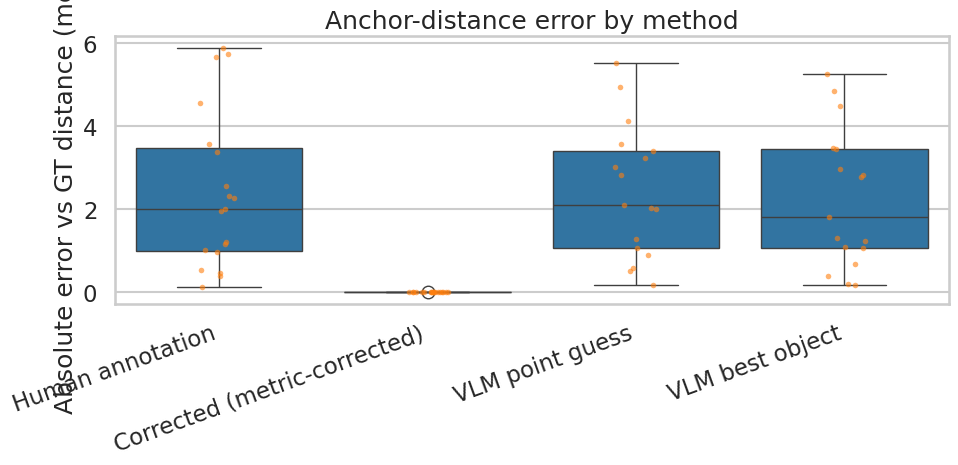

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="method", y="abs_error_m")
sns.stripplot(data=plot_df, x="method", y="abs_error_m", size=4, alpha=0.6)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Absolute error vs GT distance (meters)")
plt.xlabel("")
plt.title("Anchor-distance error by method")
plt.tight_layout()
plt.show()

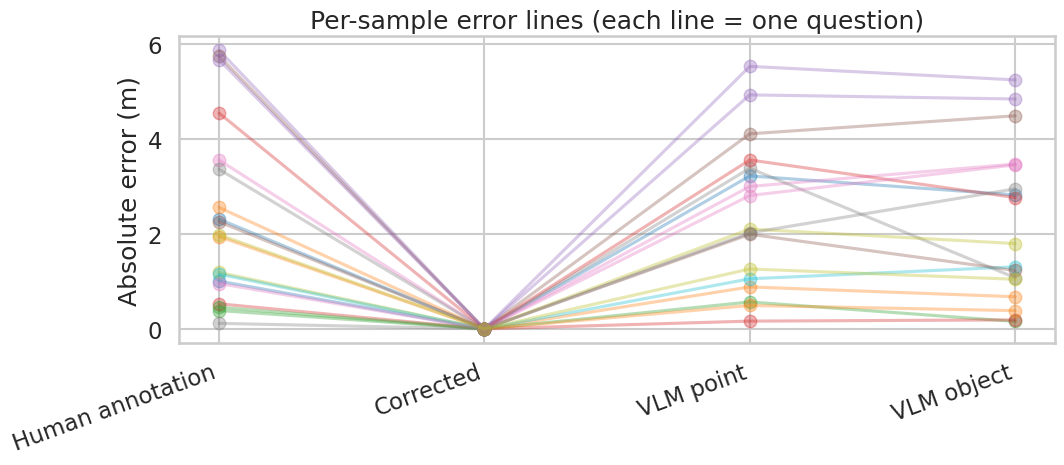

In [11]:
pivot_err = plot_df.pivot_table(index=["id","scene"], columns="method", values="abs_error_m").reset_index()

plt.figure(figsize=(11, 5))
for _, r in pivot_err.iterrows():
    y = [
        r.get("Human annotation", np.nan),
        r.get("Corrected (metric-corrected)", np.nan),
        r.get("VLM point guess", np.nan),
        r.get("VLM best object", np.nan),
    ]
    plt.plot(range(len(y)), y, marker="o", alpha=0.35)

plt.xticks(
    range(4),
    ["Human annotation", "Corrected", "VLM point", "VLM object"],
    rotation=20, ha="right"
)
plt.ylabel("Absolute error (m)")
plt.title("Per-sample error lines (each line = one question)")
plt.tight_layout()
plt.show()

In [12]:
summary = plot_df.groupby("method")["abs_error_m"].agg(["count","mean","median","std"]).sort_values("median")
display(summary)

# Win-rate: which method has lowest error per sample
wins = pivot_err.copy()
methods = ["Human annotation", "Corrected (metric-corrected)", "VLM point guess", "VLM best object"]
wins["winner"] = wins[methods].idxmin(axis=1)
display(wins["winner"].value_counts())

,count,mean,median,std
method,,,,
Corrected (metric-corrected),19,3.213803e-16,2.220446e-16,3.223998e-16
VLM best object,17,2.231279e+00,1.798459e+00,1.664711e+00
Human annotation,19,2.401021e+00,1.985813e+00,1.899338e+00
VLM point guess,17,2.418378e+00,2.104473e+00,1.590805e+00


winner
Corrected (metric-corrected)    19
Name: count, dtype: int64

In [13]:
from pathlib import Path
OBJ_JSON = Path("/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_object_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json")
POINT_JSON = Path("/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_point_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json")  # adjust if filename differs

def load_json(p: Path):
    with open(p, "r") as f:
        return json.load(f)

obj_data = load_json(OBJ_JSON)
point_data = load_json(POINT_JSON)

len(obj_data), len(point_data)

(19, 19)

In [14]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

def parse_episode_key(k: str):
    """
    Expected keys like: '0_00410-v7DzfFFEpsD_1'
    Returns: qid(int), scene(str), split_id(str/int) (last token)
    """
    parts = str(k).split("_")
    if len(parts) >= 3:
        try:
            qid = int(parts[0])
        except:
            qid = None
        scene = parts[1]
        split_id = parts[2]
        try:
            split_id = int(split_id)
        except:
            pass
        return qid, scene, split_id
    return None, None, None

def safe_xyz(v):
    if isinstance(v, (list, tuple)) and len(v) == 3:
        try:
            return float(v[0]), float(v[1]), float(v[2])
        except:
            pass
    return (np.nan, np.nan, np.nan)

def load_benchmark_point_df(json_path: str, bench_tag: str) -> pd.DataFrame:
    json_path = Path(json_path)
    assert json_path.exists(), f"File not found: {json_path}"

    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for ep_key, payload in (data or {}).items():
        qid, scene, split_id = parse_episode_key(ep_key)
        payload = payload or {}

        metrics = payload.get("metrics", {}) or {}
        final_pred = metrics.get("final_pred", None) or {}

        # --- point coordinate field (your new benchmark JSON uses this) ---
        tp = final_pred.get("target_point_xyz", None)

        # --- fallbacks in case formats drift ---
        if tp is None:
            tp = final_pred.get("target_xyz_hab", None)
        if tp is None:
            tp = (((final_pred.get("selector", {}) or {}).get("point_guess", {}) or {}).get("target_xyz_hab", None))

        x, y, z = safe_xyz(tp)

        rows.append({
            "episode_key": ep_key,
            "qid": qid,
            "id": (qid + 1) if qid is not None else np.nan,  # eval_df is 1-based
            "scene": scene,
            "split_id": split_id,

            f"{bench_tag}_Success": bool(payload.get("Success", False)),
            f"{bench_tag}_is_confident": metrics.get("is_confident"),
            f"{bench_tag}_confidence": metrics.get("confidence_level"),
            f"{bench_tag}_vlm_steps": metrics.get("vlm_steps"),
            f"{bench_tag}_overall_steps": metrics.get("overall_steps"),
            f"{bench_tag}_traj_length": metrics.get("traj_length"),

            f"{bench_tag}_pt_x": x,
            f"{bench_tag}_pt_y": y,
            f"{bench_tag}_pt_z": z,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")

    # If duplicates happen for same (id, scene), keep a "successful" one if possible
    df = df.sort_values([f"{bench_tag}_Success"]).drop_duplicates(subset=["id", "scene"], keep="last")

    return df

In [15]:
BENCH_OBJ_JSON = "/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_object_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json"
BENCH_PT_JSON  = "/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_point_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json"

# Choose tags that will appear in column names
TAG_OBJ2 = "bench_obj2"   # benchmark run that answered "object" but also includes target_point_xyz in your format
TAG_PT2  = "bench_pt2"    # benchmark run that answered "point"

df_bench_obj2 = load_benchmark_point_df(BENCH_OBJ_JSON, TAG_OBJ2)
df_bench_pt2  = load_benchmark_point_df(BENCH_PT_JSON,  TAG_PT2)

# Merge into eval_df on (id, scene)
eval_df = eval_df.copy()
eval_df["id"] = pd.to_numeric(eval_df["id"], errors="coerce").astype("Int64")

# Drop only 'qid' (we want to keep episode_key/split_id but avoid duplicate 'qid')
df_bench_obj2 = df_bench_obj2.drop(columns=["qid"], errors="ignore")
df_bench_pt2  = df_bench_pt2.drop(columns=["qid"], errors="ignore")

# Merge with explicit suffixes so overlapping columns from benchmarks are namespaced
# right-side columns will get '_obj' or '_pt' suffixes when they overlap with eval_df
eval_df = eval_df.merge(df_bench_obj2, on=["id","scene"], how="left", suffixes=("","_obj"))
eval_df = eval_df.merge(df_bench_pt2,  on=["id","scene"], how="left", suffixes=("","_pt"))

# Compute anchor->benchmark_point distances
anchor = eval_df[["anchor_x","anchor_y","anchor_z"]].to_numpy(dtype=float)

for TAG in [TAG_OBJ2, TAG_PT2]:
    pt = eval_df[[f"{TAG}_pt_x", f"{TAG}_pt_y", f"{TAG}_pt_z"]].to_numpy(dtype=float)
    eval_df[f"anchor_to_{TAG}_point_dist_m"] = np.linalg.norm(pt - anchor, axis=1)

    # Optional but super useful: absolute error vs the requested metric distance
    eval_df[f"abs_err_{TAG}_vs_gt_m"] = np.abs(eval_df[f"anchor_to_{TAG}_point_dist_m"] - eval_df["gt_metric_distance_m"])

In [16]:
# The original cell referenced undefined variables (obj_keep, point_keep).
# Replace with a safe copy of `eval_df` and show a preview.
merged = eval_df.copy()
merged["id"] = pd.to_numeric(merged["id"], errors="coerce").astype("Int64")
# If you need to merge additional benchmark tables, use the already-loaded
# `df_bench_obj2` and `df_bench_pt2` DataFrames (they were merged earlier in the notebook).
merged.head(10)

,id,scene,msp_question,gt_metric_distance_m,ann_x,ann_y,ann_z,anchor_x,anchor_y,anchor_z,corr_x,corr_y,corr_z,anchor_to_ann_dist_m,anchor_to_corr_dist_m,vlm_success,vlm_suggested_target_x,vlm_suggested_target_y,vlm_suggested_target_z,vlm_suggested_object_x,vlm_suggested_object_y,vlm_suggested_object_z,anchor_to_vlm_point_dist_m,anchor_to_vlm_object_dist_m,err_ann_m,err_corr_m,err_vlm_point_m,err_vlm_obj_m,episode_key,split_id,bench_obj2_Success,bench_obj2_is_confident,bench_obj2_confidence,bench_obj2_vlm_steps,bench_obj2_overall_steps,bench_obj2_traj_length,bench_obj2_pt_x,bench_obj2_pt_y,bench_obj2_pt_z,episode_key_pt,split_id_pt,bench_pt2_Success,bench_pt2_is_confident,bench_pt2_confidence,bench_pt2_vlm_steps,bench_pt2_overall_steps,bench_pt2_traj_length,bench_pt2_pt_x,bench_pt2_pt_y,bench_pt2_pt_z,anchor_to_bench_obj2_point_dist_m,abs_err_bench_obj2_vs_gt_m,anchor_to_bench_pt2_point_dist_m,abs_err_bench_pt2_vs_gt_m
0,1,00410-v7DzfFFEpsD,What object is 3.0 meters in front of the 2 se...,3.0,12.270763,0.626357,-0.159691,8.274635,0.488885,-0.412103,11.266905,0.591823,-0.223099,4.006451,3.0,True,14.068377,0.607284,1.859091,13.787545,0.425490,1.463109,6.224130,5.823454,1.006451,1.332268e-15,3.224130,2.823454,0_00410-v7DzfFFEpsD_1,1.0,True,True,0.9,1.0,1.0,3.065360,NaN,NaN,NaN,0_00410-v7DzfFFEpsD_1,1.0,True,True,1.0,2.0,2.0,3.686732,13.780269,-1.466907,0.417574,NaN,NaN,5.901313,2.901313
1,2,00262-1xGrZPxG1Hz,What object is 1.8 meters in front of the floo...,1.8,-4.610894,1.591614,1.170438,-1.035627,0.518089,0.874393,-2.754193,1.034113,1.016696,3.744681,1.8,True,-2.258970,1.386000,3.100219,-1.672395,1.832760,2.874992,2.684053,2.477142,1.944681,2.220446e-16,0.884053,0.677142,1_00262-1xGrZPxG1Hz_0,0.0,False,False,0.0,3.0,2.0,3.560472,NaN,NaN,NaN,1_00262-1xGrZPxG1Hz_0,0.0,False,False,0.0,3.0,2.0,4.473312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,00256-92vYG1q49FY,Where is 2 meter in front of air conditioner?,2.0,-0.664546,-0.608228,0.502032,-0.592708,-0.266122,-1.072894,-0.681768,-0.690241,0.879589,1.613254,2.0,True,0.514973,-1.171635,-3.204222,0.564412,-1.262222,-2.105005,2.566996,1.842931,0.386746,0.000000e+00,0.566996,0.157069,2_00256-92vYG1q49FY_0,0.0,False,False,0.0,3.0,2.0,1.627980,NaN,NaN,NaN,2_00256-92vYG1q49FY_0,0.0,True,True,1.0,0.0,0.0,0.000000,-0.777169,1.936678,-2.367948,NaN,NaN,2.561937,0.561937
3,4,00525-iKFn6fzyRqs,Where is 2.2 meters right of the bed?,2.2,-0.804381,1.160079,2.587379,-0.824080,0.620257,-0.086800,-0.808195,1.055567,2.069645,2.728192,2.2,True,-0.326325,2.929523,-0.019697,-1.678033,0.465808,1.727366,2.363254,2.011042,0.528192,0.000000e+00,0.163254,0.188958,3_00525-iKFn6fzyRqs_1,1.0,False,False,0.0,3.0,2.0,5.725538,NaN,NaN,NaN,3_00525-iKFn6fzyRqs_1,1.0,True,True,1.0,1.0,1.0,2.110153,1.812554,-0.141242,0.675496,NaN,NaN,2.848300,0.648300
4,5,00366-fxbzYAGkrtm,Where is 1 meters right of the bathtub?,1.0,0.235436,1.136391,13.243641,1.531338,0.308540,6.544282,1.342804,0.428980,7.518935,6.873581,1.0,True,1.167214,0.458121,13.066575,0.380369,0.687248,12.674901,6.534162,6.249211,5.873581,6.661338e-16,5.534162,5.249211,4_00366-fxbzYAGkrtm_1,1.0,False,False,0.0,3.0,2.0,3.919276,NaN,NaN,NaN,4_00366-fxbzYAGkrtm_1,1.0,True,True,0.9,0.0,0.0,0.000000,2.780556,-12.303245,0.437346,NaN,NaN,14.068132,13.068132
5,6,00388-pcpn6mFqFCg,Where is 2 meters behind the piano stool?,2.0,12.949680,0.724510,1.971416,5.251103,0.255965,1.202701,7.237567,0.376864,1.401053,7.751035,2.0,True,11.298995,0.401982,0.330038,11.156693,0.794718,3.844335,6.112271,6.491878,5.751035,6.661338e-16,4.112271,4.491878,5_00388-pcpn6mFqFCg_0,0.0,True,True,0.9,2.0,2.0,1.921912,NaN,NaN,NaN,5_00388-pcpn6mFqFCg_0,0.0,True,True,1.0,0.0,0.0,0.000000,11.260400,-0.924400,-0.936400,NaN,NaN,6.486961,4.486961
6,7,00706-YHmAkqgwe2p,Where is 1 meter above the tv?,1.0,-9.173982,1.907538,0.762265,-4.816269,0.618242,0.398071,-5.772115,0.901044,0.477955,4.559011,1.0,True,-8.649687,0.878702,1.519565,-9.221124,1.271504,0.850477,4.002584,4.475954,3.559011,2.220446e-16,3.002584,3.475954,

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- numeric cleanup (safe) ---
num_cols = [
    "anchor_to_ann_dist_m",
    "anchor_to_corr_dist_m",
    "anchor_to_vlm_point_dist_m",
    "anchor_to_vlm_object_dist_m",
    "gt_metric_distance_m",
    "obj_confidence","pt_confidence",
    "obj_traj_length","pt_traj_length"
]
for c in num_cols:
    if c in merged.columns:
        merged[c] = pd.to_numeric(merged[c], errors="coerce")

# --- Differences of interest ---
# How much worse/better is VLM point distance vs corrected metric?
if "anchor_to_vlm_point_dist_m" in merged.columns and "anchor_to_corr_dist_m" in merged.columns:
    merged["delta_pt_vs_corr_m"] = merged["anchor_to_vlm_point_dist_m"] - merged["anchor_to_corr_dist_m"]

# How much worse/better is VLM object distance vs corrected metric?
if "anchor_to_vlm_object_dist_m" in merged.columns and "anchor_to_corr_dist_m" in merged.columns:
    merged["delta_obj_vs_corr_m"] = merged["anchor_to_vlm_object_dist_m"] - merged["anchor_to_corr_dist_m"]

# If you also want vs annotation distance:
if "anchor_to_vlm_point_dist_m" in merged.columns and "anchor_to_ann_dist_m" in merged.columns:
    merged["delta_pt_vs_ann_m"] = merged["anchor_to_vlm_point_dist_m"] - merged["anchor_to_ann_dist_m"]

if "anchor_to_vlm_object_dist_m" in merged.columns and "anchor_to_ann_dist_m" in merged.columns:
    merged["delta_obj_vs_ann_m"] = merged["anchor_to_vlm_object_dist_m"] - merged["anchor_to_ann_dist_m"]

# Compare point vs object directly (who is closer to corrected?)
if "anchor_to_vlm_point_dist_m" in merged.columns and "anchor_to_vlm_object_dist_m" in merged.columns:
    merged["delta_pt_minus_obj_m"] = merged["anchor_to_vlm_point_dist_m"] - merged["anchor_to_vlm_object_dist_m"]

merged.head(10)

,id,scene,msp_question,gt_metric_distance_m,ann_x,ann_y,ann_z,anchor_x,anchor_y,anchor_z,corr_x,corr_y,corr_z,anchor_to_ann_dist_m,anchor_to_corr_dist_m,vlm_success,vlm_suggested_target_x,vlm_suggested_target_y,vlm_suggested_target_z,vlm_suggested_object_x,vlm_suggested_object_y,vlm_suggested_object_z,anchor_to_vlm_point_dist_m,anchor_to_vlm_object_dist_m,err_ann_m,err_corr_m,err_vlm_point_m,err_vlm_obj_m,episode_key,split_id,bench_obj2_Success,bench_obj2_is_confident,bench_obj2_confidence,bench_obj2_vlm_steps,bench_obj2_overall_steps,bench_obj2_traj_length,bench_obj2_pt_x,bench_obj2_pt_y,bench_obj2_pt_z,episode_key_pt,split_id_pt,bench_pt2_Success,bench_pt2_is_confident,bench_pt2_confidence,bench_pt2_vlm_steps,bench_pt2_overall_steps,bench_pt2_traj_length,bench_pt2_pt_x,bench_pt2_pt_y,bench_pt2_pt_z,anchor_to_bench_obj2_point_dist_m,abs_err_bench_obj2_vs_gt_m,anchor_to_bench_pt2_point_dist_m,abs_err_bench_pt2_vs_gt_m,delta_pt_vs_corr_m,delta_obj_vs_corr_m,delta_pt_vs_ann_m,delta_obj_vs_ann_m,delta_pt_minus_obj_m
0,1,00410-v7DzfFFEpsD,What object is 3.0 meters in front of the 2 se...,3.0,12.270763,0.626357,-0.159691,8.274635,0.488885,-0.412103,11.266905,0.591823,-0.223099,4.006451,3.0,True,14.068377,0.607284,1.859091,13.787545,0.425490,1.463109,6.224130,5.823454,1.006451,1.332268e-15,3.224130,2.823454,0_00410-v7DzfFFEpsD_1,1.0,True,True,0.9,1.0,1.0,3.065360,NaN,NaN,NaN,0_00410-v7DzfFFEpsD_1,1.0,True,True,1.0,2.0,2.0,3.686732,13.780269,-1.466907,0.417574,NaN,NaN,5.901313,2.901313,3.224130,2.823454,2.217679,1.817003,0.400676
1,2,00262-1xGrZPxG1Hz,What object is 1.8 meters in front of the floo...,1.8,-4.610894,1.591614,1.170438,-1.035627,0.518089,0.874393,-2.754193,1.034113,1.016696,3.744681,1.8,True,-2.258970,1.386000,3.100219,-1.672395,1.832760,2.874992,2.684053,2.477142,1.944681,2.220446e-16,0.884053,0.677142,1_00262-1xGrZPxG1Hz_0,0.0,False,False,0.0,3.0,2.0,3.560472,NaN,NaN,NaN,1_00262-1xGrZPxG1Hz_0,0.0,False,False,0.0,3.0,2.0,4.473312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.884053,0.677142,-1.060628,-1.267539,0.206911
2,3,00256-92vYG1q49FY,Where is 2 meter in front of air conditioner?,2.0,-0.664546,-0.608228,0.502032,-0.592708,-0.266122,-1.072894,-0.681768,-0.690241,0.879589,1.613254,2.0,True,0.514973,-1.171635,-3.204222,0.564412,-1.262222,-2.105005,2.566996,1.842931,0.386746,0.000000e+00,0.566996,0.157069,2_00256-92vYG1q49FY_0,0.0,False,False,0.0,3.0,2.0,1.627980,NaN,NaN,NaN,2_00256-92vYG1q49FY_0,0.0,True,True,1.0,0.0,0.0,0.000000,-0.777169,1.936678,-2.367948,NaN,NaN,2.561937,0.561937,0.566996,-0.157069,0.953742,0.229677,0.724065
3,4,00525-iKFn6fzyRqs,Where is 2.2 meters right of the bed?,2.2,-0.804381,1.160079,2.587379,-0.824080,0.620257,-0.086800,-0.808195,1.055567,2.069645,2.728192,2.2,True,-0.326325,2.929523,-0.019697,-1.678033,0.465808,1.727366,2.363254,2.011042,0.528192,0.000000e+00,0.163254,0.188958,3_00525-iKFn6fzyRqs_1,1.0,False,False,0.0,3.0,2.0,5.725538,NaN,NaN,NaN,3_00525-iKFn6fzyRqs_1,1.0,True,True,1.0,1.0,1.0,2.110153,1.812554,-0.141242,0.675496,NaN,NaN,2.848300,0.648300,0.163254,-0.188958,-0.364937,-0.717150,0.352213
4,5,00366-fxbzYAGkrtm,Where is 1 meters right of the bathtub?,1.0,0.235436,1.136391,13.243641,1.531338,0.308540,6.544282,1.342804,0.428980,7.518935,6.873581,1.0,True,1.167214,0.458121,13.066575,0.380369,0.687248,12.674901,6.534162,6.249211,5.873581,6.661338e-16,5.534162,5.249211,4_00366-fxbzYAGkrtm_1,1.0,False,False,0.0,3.0,2.0,3.919276,NaN,NaN,NaN,4_00366-fxbzYAGkrtm_1,1.0,True,True,0.9,0.0,0.0,0.000000,2.780556,-12.303245,0.437346,NaN,NaN,14.068132,13.068132,5.534162,5.249211,-0.339419,-0.624370,0.284950
5,6,00388-pcpn6mFqFCg,Where is 2 meters behind the piano stool?,2.0,12.949680,0.724510,1.971416,5.251103,0.255965,1.202701,7.237567,0.376864,1.401053,7.751035,2.0,True,11.298995,0.401982,0.330038,11.156693,0.794718,3.844335,6.112271,6.491878,5.751035,6.661338e-16,4.112271,4.491878,5_00388-pcpn6mFqFCg_0,0.0,True,True,0.9,2.0,2.0,1.921912,NaN,NaN,NaN,5_00388-pcpn6mFqFCg_0,0.0,True,True,1.0,0.0,0.0,0.000000

In [18]:
summary = {
    "N_total": len(merged),
    "obj_success_rate": merged["obj_Success"].mean() if "obj_Success" in merged.columns else np.nan,
    "pt_success_rate": merged["pt_Success"].mean() if "pt_Success" in merged.columns else np.nan,
    "obj_mean_conf": merged.loc[merged["obj_Success"]==True, "obj_confidence"].mean() if "obj_confidence" in merged.columns else np.nan,
    "pt_mean_conf": merged.loc[merged["pt_Success"]==True, "pt_confidence"].mean() if "pt_confidence" in merged.columns else np.nan,
}
pd.Series(summary)

N_total             44.0
obj_success_rate     NaN
pt_success_rate      NaN
obj_mean_conf        NaN
pt_mean_conf         NaN
dtype: float64

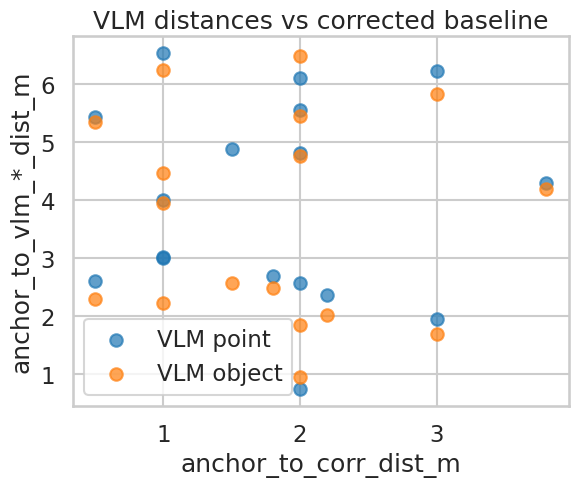

In [19]:
plt.figure()
plt.scatter(merged["anchor_to_corr_dist_m"], merged["anchor_to_vlm_point_dist_m"], label="VLM point", alpha=0.7)
plt.scatter(merged["anchor_to_corr_dist_m"], merged["anchor_to_vlm_object_dist_m"], label="VLM object", alpha=0.7)
plt.xlabel("anchor_to_corr_dist_m")
plt.ylabel("anchor_to_vlm_*_dist_m")
plt.title("VLM distances vs corrected baseline")
plt.legend()
plt.show()

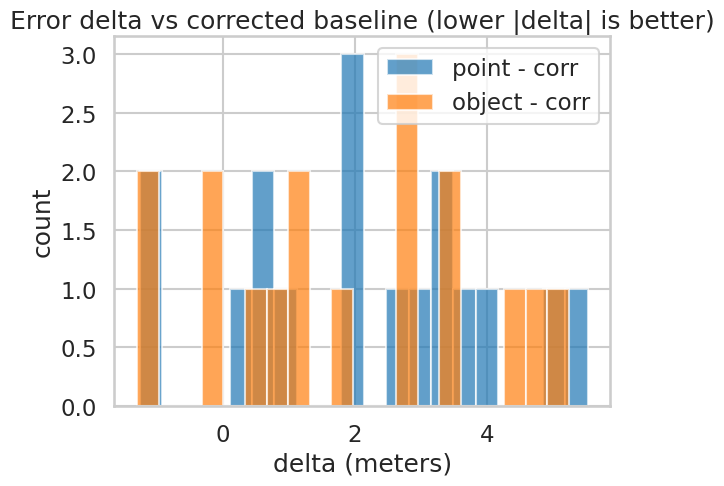

In [20]:
plt.figure()
if "delta_pt_vs_corr_m" in merged.columns:
    plt.hist(merged["delta_pt_vs_corr_m"].dropna(), bins=20, alpha=0.7, label="point - corr")
if "delta_obj_vs_corr_m" in merged.columns:
    plt.hist(merged["delta_obj_vs_corr_m"].dropna(), bins=20, alpha=0.7, label="object - corr")
plt.xlabel("delta (meters)")
plt.ylabel("count")
plt.title("Error delta vs corrected baseline (lower |delta| is better)")
plt.legend()
plt.show()

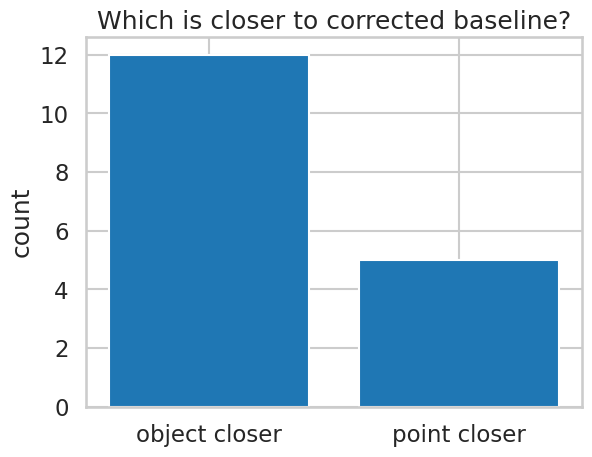

In [21]:
if "delta_pt_minus_obj_m" in merged.columns:
    tmp = merged.dropna(subset=["delta_pt_minus_obj_m"]).copy()
    tmp["winner"] = np.where(tmp["delta_pt_minus_obj_m"] < 0, "point closer", "object closer")
    win_counts = tmp["winner"].value_counts()

    plt.figure()
    plt.bar(win_counts.index, win_counts.values)
    plt.ylabel("count")
    plt.title("Which is closer to corrected baseline?")
    plt.show()

In [22]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

def parse_episode_key(k: str):
    """
    Expected keys like: '0_00410-v7DzfFFEpsD_1'
    Returns: qid(int), scene(str), split_id(str/int) (last token)
    """
    parts = str(k).split("_")
    if len(parts) >= 3:
        try:
            qid = int(parts[0])
        except:
            qid = None
        scene = parts[1]
        split_id = parts[2]
        try:
            split_id = int(split_id)
        except:
            pass
        return qid, scene, split_id
    return None, None, None

def safe_xyz(v):
    if isinstance(v, (list, tuple)) and len(v) == 3:
        try:
            return float(v[0]), float(v[1]), float(v[2])
        except:
            pass
    return (np.nan, np.nan, np.nan)

def load_benchmark_point_df(json_path: str, bench_tag: str) -> pd.DataFrame:
    json_path = Path(json_path)
    assert json_path.exists(), f"File not found: {json_path}"

    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for ep_key, payload in (data or {}).items():
        qid, scene, split_id = parse_episode_key(ep_key)
        payload = payload or {}

        metrics = payload.get("metrics", {}) or {}
        final_pred = metrics.get("final_pred", None) or {}

        # --- point coordinate field (your new benchmark JSON uses this) ---
        tp = final_pred.get("target_point_xyz", None)

        # --- fallbacks in case formats drift ---
        if tp is None:
            tp = final_pred.get("target_xyz_hab", None)
        if tp is None:
            tp = (((final_pred.get("selector", {}) or {}).get("point_guess", {}) or {}).get("target_xyz_hab", None))

        x, y, z = safe_xyz(tp)

        rows.append({
            "episode_key": ep_key,
            "qid": qid,
            "id": (qid + 1) if qid is not None else np.nan,  # eval_df is 1-based
            "scene": scene,
            "split_id": split_id,

            f"{bench_tag}_Success": bool(payload.get("Success", False)),
            f"{bench_tag}_is_confident": metrics.get("is_confident"),
            f"{bench_tag}_confidence": metrics.get("confidence_level"),
            f"{bench_tag}_vlm_steps": metrics.get("vlm_steps"),
            f"{bench_tag}_overall_steps": metrics.get("overall_steps"),
            f"{bench_tag}_traj_length": metrics.get("traj_length"),

            f"{bench_tag}_pt_x": x,
            f"{bench_tag}_pt_y": y,
            f"{bench_tag}_pt_z": z,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")

    # If duplicates happen for same (id, scene), keep a "successful" one if possible
    df = df.sort_values([f"{bench_tag}_Success"]).drop_duplicates(subset=["id", "scene"], keep="last")

    return df

In [23]:
BENCH_OBJ_JSON = "/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_object_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json"
BENCH_PT_JSON  = "/home/artemis/project/graph_eqa_swagat/spatial_experiment/outputs_benchmark_point_2/grapheqa_spatial_gemini_habitat_benchmark/gemini_images_True.json"

# Choose tags that will appear in column names
TAG_OBJ2 = "bench_obj2"   # benchmark run that answered "object" but also includes target_point_xyz in your format
TAG_PT2  = "bench_pt2"    # benchmark run that answered "point"

df_bench_obj2 = load_benchmark_point_df(BENCH_OBJ_JSON, TAG_OBJ2)
df_bench_pt2  = load_benchmark_point_df(BENCH_PT_JSON,  TAG_PT2)

# Merge into eval_df on (id, scene)
eval_df = eval_df.copy()
eval_df["id"] = pd.to_numeric(eval_df["id"], errors="coerce").astype("Int64")

# Drop only 'qid' (we want to keep episode_key/split_id but avoid duplicate 'qid')
df_bench_obj2 = df_bench_obj2.drop(columns=["qid"], errors="ignore")
df_bench_pt2  = df_bench_pt2.drop(columns=["qid"], errors="ignore")

# Merge with explicit suffixes so overlapping columns from benchmarks are namespaced
# right-side columns will get '_obj' or '_pt' suffixes when they overlap with eval_df
eval_df = eval_df.merge(df_bench_obj2, on=["id","scene"], how="left", suffixes=("","_obj"))
eval_df = eval_df.merge(df_bench_pt2,  on=["id","scene"], how="left", suffixes=("","_pt"))

# Compute anchor->benchmark_point distances
anchor = eval_df[["anchor_x","anchor_y","anchor_z"]].to_numpy(dtype=float)

for TAG in [TAG_OBJ2, TAG_PT2]:
    pt = eval_df[[f"{TAG}_pt_x", f"{TAG}_pt_y", f"{TAG}_pt_z"]].to_numpy(dtype=float)
    eval_df[f"anchor_to_{TAG}_point_dist_m"] = np.linalg.norm(pt - anchor, axis=1)

    # Optional but super useful: absolute error vs the requested metric distance
    eval_df[f"abs_err_{TAG}_vs_gt_m"] = np.abs(eval_df[f"anchor_to_{TAG}_point_dist_m"] - eval_df["gt_metric_distance_m"])

In [24]:
cols = [
    "id",
    "scene",
    "gt_metric_distance_m",
    "anchor_to_ann_dist_m",
    "anchor_to_corr_dist_m",
    "anchor_to_vlm_point_dist_m",
    "anchor_to_vlm_object_dist_m",
    "err_ann_m",
    "err_corr_m",
    "err_vlm_point_m",
    "err_vlm_obj_m",
    "anchor_to_bench_pt2_point_dist_m",
    "abs_err_bench_pt2_vs_gt_m",
    "delta_pt_vs_corr_m",
    "delta_pt_vs_ann_m",
    "delta_pt_minus_obj_m",
]

merged[cols].head(20)

,id,scene,gt_metric_distance_m,anchor_to_ann_dist_m,anchor_to_corr_dist_m,anchor_to_vlm_point_dist_m,anchor_to_vlm_object_dist_m,err_ann_m,err_corr_m,err_vlm_point_m,err_vlm_obj_m,anchor_to_bench_pt2_point_dist_m,abs_err_bench_pt2_vs_gt_m,delta_pt_vs_corr_m,delta_pt_vs_ann_m,delta_pt_minus_obj_m
0,1,00410-v7DzfFFEpsD,3.0,4.006451,3.0,6.224130,5.823454,1.006451,1.332268e-15,3.224130,2.823454,5.901313,2.901313,3.224130,2.217679,0.400676
1,2,00262-1xGrZPxG1Hz,1.8,3.744681,1.8,2.684053,2.477142,1.944681,2.220446e-16,0.884053,0.677142,NaN,NaN,0.884053,-1.060628,0.206911
2,3,00256-92vYG1q49FY,2.0,1.613254,2.0,2.566996,1.842931,0.386746,0.000000e+00,0.566996,0.157069,2.561937,0.561937,0.566996,0.953742,0.724065
3,4,00525-iKFn6fzyRqs,2.2,2.728192,2.2,2.363254,2.011042,0.528192,0.000000e+00,0.163254,0.188958,2.848300,0.648300,0.163254,-0.364937,0.352213
4,5,00366-fxbzYAGkrtm,1.0,6.873581,1.0,6.534162,6.249211,5.873581,6.661338e-16,5.534162,5.249211,14.068132,13.068132,5.534162,-0.339419,0.284950
5,6,00388-pcpn6mFqFCg,2.0,7.751035,2.0,6.112271,6.491878,5.751035,6.661338e-16,4.112271,4.491878,6.486961,4.486961,4.112271,-1.638764,-0.379607
6,7,00706-YHmAkqgwe2p,1.0,4.559011,1.0,4.002584,4.475954,3.559011,2.220446e-16,3.002584,3.475954,4.575354,3.575354,3.002584,-0.556427,-0.473370
7,8,00582-TYDavTf8oyy,1.5,1.384289,1.5,4.886262,2.577682,0.115711,0.000000e+00,3.386262,1.077682,8.704875,7.204875,3.386262,3.501973,2.308579
8,9,00557-fRZhp6vWGw7,0.5,1.690146,0.5,2.604473,2.298459,1.190146,1.110223e-16,2.104473,1.798459,NaN,NaN,2.104473,0.914327,0.306015
9,10,00025-ixTj1aTMup2,3.0,4.154231,3.0,1.944712,1.691801,1.154231,4.440892e-16,1.055288,1.308199,2.481328,0.518672,-1.055288,-2.209519,0.252911


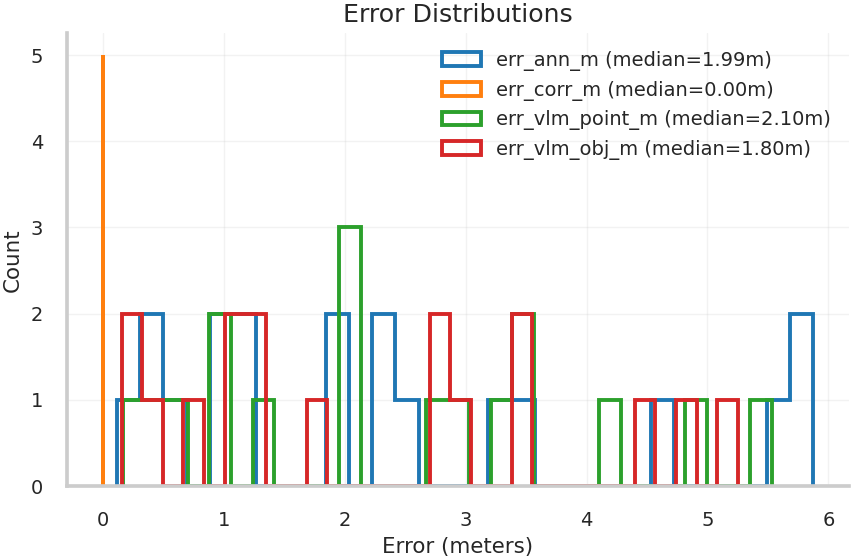

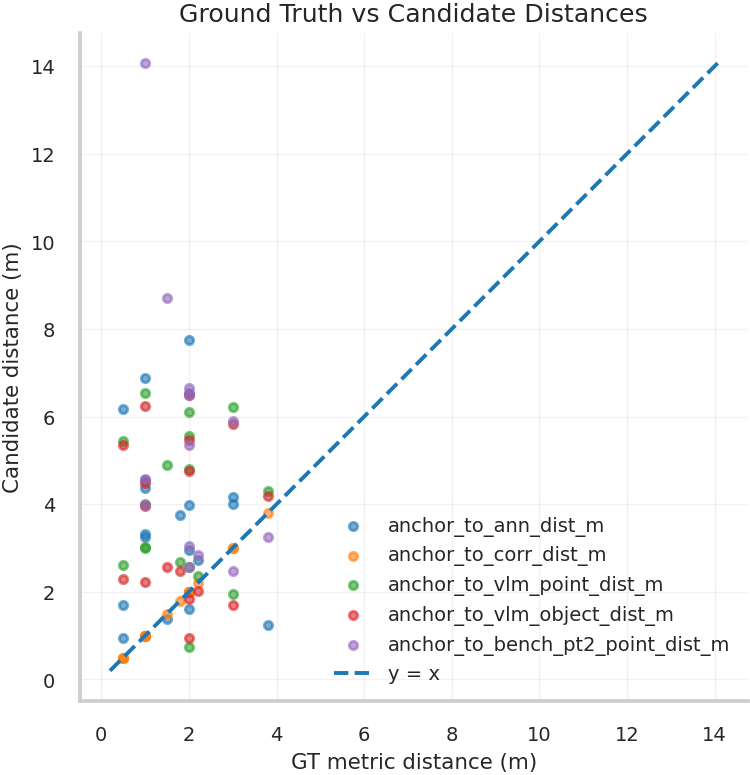

/tmp/ipykernel_635511/21587666.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


ValueError: Dimensions of labels and X must be compatible

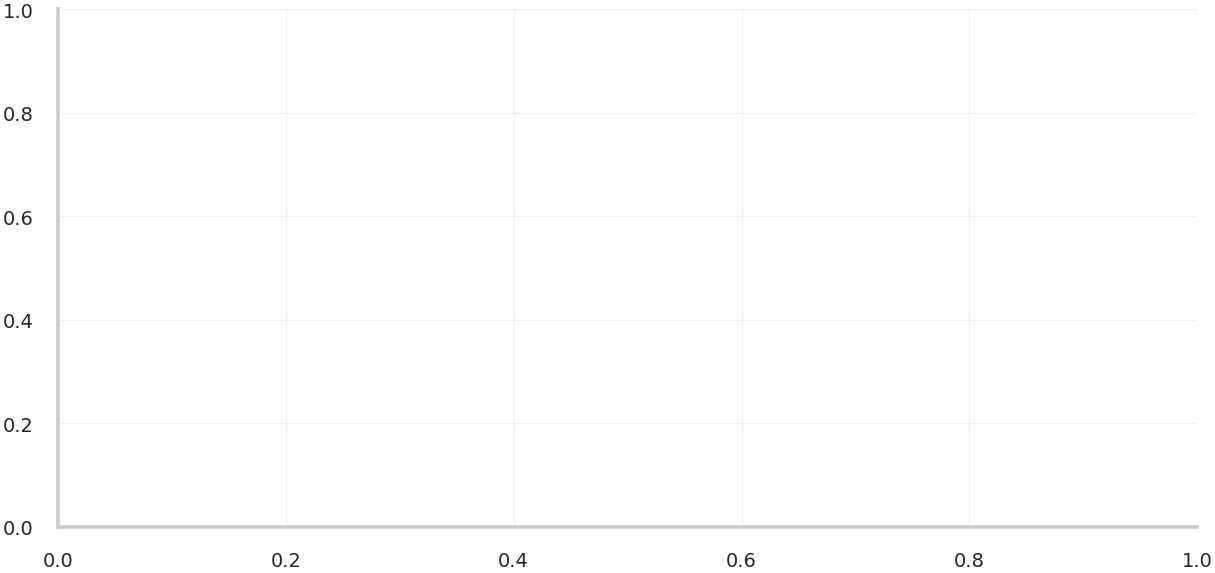

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) Pick the exact view
# ----------------------------
cols = [
    "id","scene","gt_metric_distance_m",
    "anchor_to_ann_dist_m","anchor_to_corr_dist_m",
    "anchor_to_vlm_point_dist_m","anchor_to_vlm_object_dist_m",
    "err_ann_m","err_corr_m","err_vlm_point_m","err_vlm_obj_m",
    "anchor_to_bench_pt2_point_dist_m",
    "abs_err_bench_pt2_vs_gt_m",
    "delta_pt_vs_corr_m","delta_pt_vs_ann_m","delta_pt_minus_obj_m",
]
df = merged.loc[:, [c for c in cols if c in merged.columns]].copy()

# Optional: drop rows with missing key metrics
df = df.dropna(subset=["gt_metric_distance_m"]).reset_index(drop=True)

# ----------------------------
# 2) Research-grade plot defaults
# ----------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

set_pub_style()

def _clean_series(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce")
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# ----------------------------
# 3) Plot A: Error distributions (hist + median)
# ----------------------------
def plot_error_histograms(df: pd.DataFrame, savepath=None):
    err_cols = [c for c in ["err_ann_m","err_corr_m","err_vlm_point_m","err_vlm_obj_m"] if c in df.columns]
    if not err_cols:
        print("No error columns found.")
        return

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for c in err_cols:
        s = _clean_series(df[c])
        ax.hist(s, bins=30, histtype="step", linewidth=2, label=f"{c} (median={np.median(s):.2f}m)")
    ax.set_title("Error Distributions")
    ax.set_xlabel("Error (meters)")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    if savepath:
        fig.savefig(savepath)
    plt.show()

# ----------------------------
# 4) Plot B: GT distance vs anchor distances (scatter + y=x)
# ----------------------------
def plot_gt_vs_distances(df: pd.DataFrame, savepath=None):
    gt = _clean_series(df["gt_metric_distance_m"]) if "gt_metric_distance_m" in df.columns else None
    if gt is None or gt.empty:
        print("Missing gt_metric_distance_m.")
        return

    x = df["gt_metric_distance_m"]
    candidates = [
        "anchor_to_ann_dist_m",
        "anchor_to_corr_dist_m",
        "anchor_to_vlm_point_dist_m",
        "anchor_to_vlm_object_dist_m",
        "anchor_to_bench_pt2_point_dist_m",
    ]
    ycols = [c for c in candidates if c in df.columns]

    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    # plot each relationship
    for c in ycols:
        mask = np.isfinite(x) & np.isfinite(df[c])
        ax.scatter(x[mask], df.loc[mask, c], s=18, alpha=0.6, label=c)

    # y=x reference line
    all_vals = pd.concat([x] + [df[c] for c in ycols], axis=1).to_numpy()
    finite = all_vals[np.isfinite(all_vals)]
    if finite.size:
        lo, hi = np.min(finite), np.max(finite)
        ax.plot([lo, hi], [lo, hi], linewidth=2, linestyle="--", label="y = x")

    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Ground Truth vs Candidate Distances")
    ax.set_xlabel("GT metric distance (m)")
    ax.set_ylabel("Candidate distance (m)")
    ax.legend(frameon=False, loc="best")
    if savepath:
        fig.savefig(savepath)
    plt.show()

# ----------------------------
# 5) Plot C: Scene-wise boxplots for key errors (top-N scenes)
# ----------------------------
def plot_scene_boxplots(df: pd.DataFrame, top_n_scenes=12, savepath=None, min_n=3, method=None):
    if "scene" not in df.columns:
        print("Missing scene.")
        return

    # Choose method
    err_cols = [c for c in ["err_ann_m","err_corr_m","err_vlm_point_m","err_vlm_obj_m"] if c in df.columns]
    if not err_cols:
        print("No error columns found.")
        return
    if method is None:
        method = "err_corr_m" if "err_corr_m" in err_cols else err_cols[0]
    if method not in df.columns:
        print(f"Method {method} not in df.")
        return

    # pick top scenes by row count
    top_scenes = df["scene"].value_counts().head(top_n_scenes).index.tolist()
    sub = df[df["scene"].isin(top_scenes)].copy()

    def _clean_series(s: pd.Series):
        s = pd.to_numeric(s, errors="coerce")
        return s.replace([np.inf, -np.inf], np.nan).dropna()

    data, labels = [], []
    for sc in top_scenes:
        s = _clean_series(sub.loc[sub["scene"] == sc, method])
        if len(s) >= min_n:
            data.append(s.to_numpy())
            labels.append(sc)

    if len(data) == 0:
        print(f"No scenes had >= {min_n} valid points for {method}.")
        return

    fig, ax = plt.subplots(figsize=(10.5, 4.8))

    # IMPORTANT: Matplotlib sometimes prefers tick_labels over labels
    ax.boxplot(data, tick_labels=labels, showfliers=False)

    ax.set_title(f"Scene-wise Error Spread ({method}) — top {len(labels)} scenes")
    ax.set_xlabel("Scene")
    ax.set_ylabel("Error (m)")
    plt.xticks(rotation=35, ha="right")

    if savepath:
        fig.savefig(savepath)
    plt.show()

# ----------------------------
# 6) Plot D: ECDF comparison (nice for method ranking)
# ----------------------------
def plot_ecdf(df: pd.DataFrame, savepath=None):
    err_cols = [c for c in ["err_ann_m","err_corr_m","err_vlm_point_m","err_vlm_obj_m"] if c in df.columns]
    if not err_cols:
        print("No error columns found.")
        return

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for c in err_cols:
        s = np.sort(_clean_series(df[c]).to_numpy())
        y = np.linspace(0, 1, len(s), endpoint=True)
        ax.plot(s, y, linewidth=2, label=c)

    ax.set_title("ECDF of Errors (lower is better)")
    ax.set_xlabel("Error (m)")
    ax.set_ylabel("Fraction ≤ error")
    ax.legend(frameon=False)
    if savepath:
        fig.savefig(savepath)
    plt.show()

# ----------------------------
# 7) Plot E: Correlation heatmap (compact + publication friendly)
# ----------------------------
def plot_corr_heatmap(df: pd.DataFrame, savepath=None):
    numeric = df.select_dtypes(include=[np.number]).copy()
    if numeric.shape[1] < 2:
        print("Not enough numeric columns for correlation.")
        return
    corr = numeric.corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8.2, 6.6))
    im = ax.imshow(corr.to_numpy(), aspect="auto")
    ax.set_title("Correlation (numeric columns)")
    ax.set_xticks(range(corr.shape[1]))
    ax.set_yticks(range(corr.shape[0]))
    ax.set_xticklabels(corr.columns, rotation=55, ha="right")
    ax.set_yticklabels(corr.index)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if savepath:
        fig.savefig(savepath)
    plt.show()

# ----------------------------
# 8) Run the suite
# ----------------------------
plot_error_histograms(df, savepath="fig_error_hist.pdf")
plot_gt_vs_distances(df, savepath="fig_gt_vs_dist.pdf")
plot_scene_boxplots(df, top_n_scenes=12, savepath="fig_scene_box.pdf")
plot_ecdf(df, savepath="fig_ecdf.pdf")
plot_corr_heatmap(df, savepath="fig_corr.pdf")